In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

=== Overall summary per method ===
                  method  best_accuracy_across_seeds  mean_best_accuracy  \
0          Random Search                      0.8940            0.851625   
1       Aquila Optimizer                      0.9120            0.911125   
2               PSO + GA                      0.9165            0.909875   
3  Blindfolded Spiderman                      0.9400            0.939141   

   std_best_accuracy  total_evaluations  worst_accuracy  median_accuracy  \
0           0.051527                 80          0.1105         0.457750   
1           0.000740                400          0.0405         0.799000   
2           0.006056                420          0.3520         0.894000   
3           0.000745                102          0.3350         0.931094   

   avg_train_time_per_seed_sec  std_train_time_per_seed_sec  \
0                  1504.213678                    22.048206   
1                  7503.941529                   236.650858   
2             

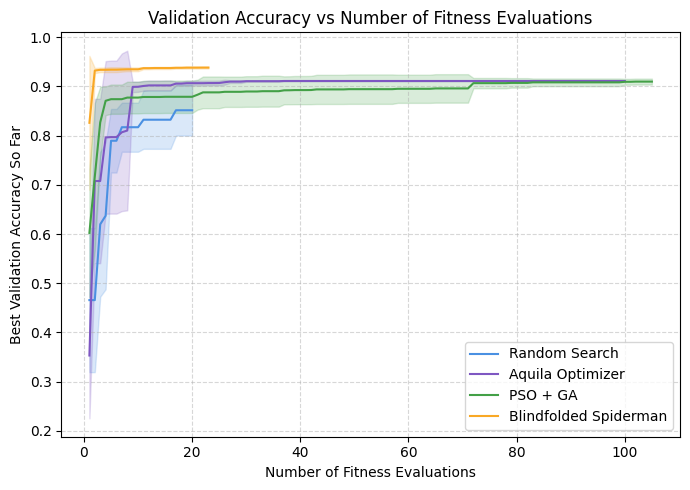

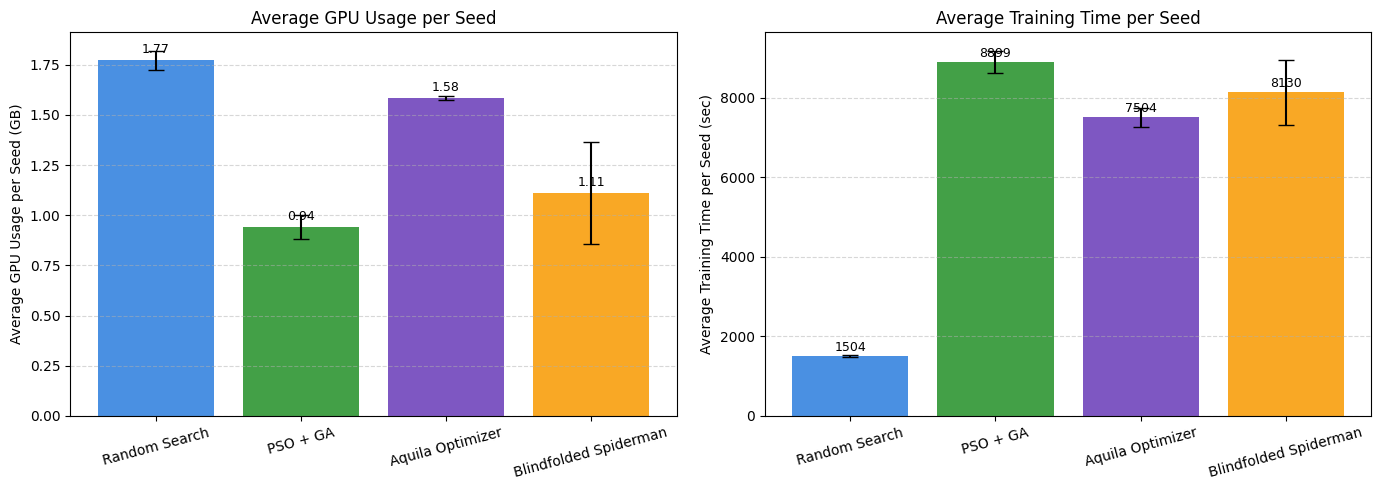

In [ ]:


with open("random_search_results.json", "r") as f:
    rs_dict = json.load(f)

with open("ao_results_all_seeds_combined.json", "r") as f:
    ao_list = json.load(f)

with open("dpso_ga_results_all_seeds.json", "r") as f:
    dpso_list = json.load(f)

with open("bso_blindfolded_all_seeds_merged.json", "r") as f:
    bso_dict = json.load(f)




def flatten_random_search(rs_dict, method_label="Random Search"):
    rows = []
    for seed_block in rs_dict["seeds_results"]:
        seed = seed_block["seed"]
        eval_idx = 0
        for trial in seed_block["trials"]:
            eval_idx += 1
            rows.append({
                "method": method_label,
                "seed": seed,
                "eval_index": eval_idx,
                "val_acc": trial["val_acc"],
                "best_so_far": trial["best_val_acc_so_far"],
                "gpu_memory_gb": trial["gpu_memory_gb"],
                "train_time_sec": trial["train_time_sec"],
            })
    return pd.DataFrame(rows)


def flatten_ao(ao_list, method_label="Aquila Optimizer"):
    ao_dict = ao_list[0]
    rows = []
    for seed_block in ao_dict["seeds_results"]:
        seed = seed_block["seed"]
        eval_idx = 0
        for trial in seed_block["trials"]:
            best_so_far = trial["best_val_acc_so_far"]
            for cand in trial["candidates"]:
                eval_idx += 1
                rows.append({
                    "method": method_label,
                    "seed": seed,
                    "eval_index": eval_idx,
                    "val_acc": cand["val_acc"],
                    "best_so_far": best_so_far,
                    "gpu_memory_gb": cand["gpu_memory_gb"],
                    "train_time_sec": cand["train_time_sec"],
                })
    return pd.DataFrame(rows)


def flatten_bso(bso_dict, method_label="Blindfolded Spiderman"):
    rows = []
    for seed_block in bso_dict["seeds_results"]:
        seed = seed_block["seed"]
        eval_idx = 0
        best_so_far = -1.0
        for traj in seed_block["trajectories"]:
            for step in traj["steps"]:
                eval_idx += 1
                val_acc = step["val_acc"]
                best_so_far = max(best_so_far, val_acc)
                rows.append({
                    "method": method_label,
                    "seed": seed,
                    "eval_index": eval_idx,
                    "val_acc": val_acc,
                    "best_so_far": best_so_far,
                    "gpu_memory_gb": step["gpu_memory_gb"],
                    "train_time_sec": step["train_time_sec"],
                })
    return pd.DataFrame(rows)


def flatten_dpso_ga(dpso_list, method_label="PSO + GA"):
    dpso_dict = dpso_list[0]
    rows = []
    for seed_block in dpso_dict["seeds_results"]:
        seed = seed_block["seed"]
        eval_idx = 0
        best_so_far = -1.0
        for trial in seed_block["trials"]:
            best_so_far = trial["best_val_acc_so_far"]
            for part in trial["particles"]:
                eval_idx += 1
                val_acc = part["val_acc"]
                rows.append({
                    "method": method_label,
                    "seed": seed,
                    "eval_index": eval_idx,
                    "val_acc": val_acc,
                    "best_so_far": best_so_far,
                    "gpu_memory_gb": part["gpu_memory_gb"],
                    "train_time_sec": part["train_time_sec"],
                })
    return pd.DataFrame(rows)


# Flatten all four methods
rs_df  = flatten_random_search(rs_dict)
ao_df  = flatten_ao(ao_list)
dpso_df = flatten_dpso_ga(dpso_list)
bso_df = flatten_bso(bso_dict)

df_all = pd.concat([rs_df, ao_df, dpso_df, bso_df], ignore_index=True)



summary_rows = []
for method in df_all["method"].unique():
    mdf = df_all[df_all["method"] == method]

    seed_best = mdf.groupby("seed")["val_acc"].max()
    best_accuracy_across_seeds = seed_best.max()
    mean_best_accuracy = seed_best.mean()
    std_best_accuracy = seed_best.std(ddof=0)

    total_evaluations = len(mdf)
    worst_accuracy = mdf["val_acc"].min()
    median_accuracy = mdf["val_acc"].median()

    seed_stats = mdf.groupby("seed").agg(
        total_train_time_sec=("train_time_sec", "sum"),
        avg_gpu_memory_gb=("gpu_memory_gb", "mean")
    )
    avg_train_time_per_seed_sec = seed_stats["total_train_time_sec"].mean()
    std_train_time_per_seed_sec = seed_stats["total_train_time_sec"].std(ddof=0)
    avg_gpu_memory_per_seed_gb = seed_stats["avg_gpu_memory_gb"].mean()
    std_gpu_memory_per_seed_gb = seed_stats["avg_gpu_memory_gb"].std(ddof=0)

    summary_rows.append({
        "method": method,
        "best_accuracy_across_seeds": best_accuracy_across_seeds,
        "mean_best_accuracy": mean_best_accuracy,
        "std_best_accuracy": std_best_accuracy,
        "total_evaluations": total_evaluations,
        "worst_accuracy": worst_accuracy,
        "median_accuracy": median_accuracy,
        "avg_train_time_per_seed_sec": avg_train_time_per_seed_sec,
        "std_train_time_per_seed_sec": std_train_time_per_seed_sec,
        "avg_gpu_memory_per_seed_gb": avg_gpu_memory_per_seed_gb,
        "std_gpu_memory_per_seed_gb": std_gpu_memory_per_seed_gb,
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Overall summary per method ===")
print(summary_df)


def build_convergence_curves(method_df):
    """
    For each seed, build an array of 'best-so-far' validation accuracy
    as a function of evaluation index (1..N).
    """
    curves = {}
    for seed, sdf in method_df.sort_values("eval_index").groupby("seed"):
        vals = sdf["val_acc"].tolist()
        best = []
        best_so_far = -1.0
        for v in vals:
            best_so_far = max(best_so_far, v)
            best.append(best_so_far)
        curves[seed] = np.array(best, dtype=float)
    return curves


def average_convergence(curves_dict):
    """
    Given {seed: curve}, truncate all to the minimum length and compute
    mean and std over seeds.
    """
    lengths = [len(v) for v in curves_dict.values()]
    min_len = min(lengths)
    stacked = np.vstack([v[:min_len] for v in curves_dict.values()])
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    x = np.arange(1, min_len + 1)
    return x, mean, std


rs_curves   = build_convergence_curves(rs_df)
ao_curves   = build_convergence_curves(ao_df)
dpso_curves = build_convergence_curves(dpso_df)
bso_curves  = build_convergence_curves(bso_df)

curves_by_method = {
    "Random Search": rs_curves,
    "Aquila Optimizer": ao_curves,
    "PSO + GA": dpso_curves,
    "Blindfolded Spiderman": bso_curves,
}

COLOR_RS  = "#4A90E2"  # blue
COLOR_AO  = "#7E57C2"  # purple
COLOR_PSO = "#43A047"  # green
COLOR_BSO = "#F9A825"  # orange

color_map = {
    "Random Search": COLOR_RS,
    "Aquila Optimizer": COLOR_AO,
    "PSO + GA": COLOR_PSO,
    "Blindfolded Spiderman": COLOR_BSO,
}

plt.figure(figsize=(7, 5))
for method, curves in curves_by_method.items():
    x, mean_y, std_y = average_convergence(curves)
    plt.plot(x, mean_y, label=method, color=color_map[method])
    plt.fill_between(x, mean_y - std_y, mean_y + std_y,
                     color=color_map[method], alpha=0.2)

plt.xlabel("Number of Fitness Evaluations")
plt.ylabel("Best Validation Accuracy So Far")
plt.title("Validation Accuracy vs Number of Fitness Evaluations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("fig_validation_accuracy_vs_fitness_evals_4methods.png", dpi=300)
plt.show()




gpu_stats = summary_df.set_index("method")[[
    "avg_gpu_memory_per_seed_gb",
    "std_gpu_memory_per_seed_gb"
]]
time_stats = summary_df.set_index("method")[[
    "avg_train_time_per_seed_sec",
    "std_train_time_per_seed_sec"
]]

methods_order = ["Random Search", "PSO + GA", "Aquila Optimizer", "Blindfolded Spiderman"]
colors_in_order = [color_map[m] for m in methods_order]

x = np.arange(len(methods_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    x,
    gpu_stats.loc[methods_order, "avg_gpu_memory_per_seed_gb"].values,
    yerr=gpu_stats.loc[methods_order, "std_gpu_memory_per_seed_gb"].values,
    capsize=6,
    color=colors_in_order,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_order, rotation=15)
axes[0].set_ylabel("Average GPU Usage per Seed (GB)")
axes[0].set_title("Average GPU Usage per Seed")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(gpu_stats.loc[methods_order, "avg_gpu_memory_per_seed_gb"].values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# Subplot 2: Training time
axes[1].bar(
    x,
    time_stats.loc[methods_order, "avg_train_time_per_seed_sec"].values,
    yerr=time_stats.loc[methods_order, "std_train_time_per_seed_sec"].values,
    capsize=6,
    color=colors_in_order,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods_order, rotation=15)
axes[1].set_ylabel("Average Training Time per Seed (sec)")
axes[1].set_title("Average Training Time per Seed")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(time_stats.loc[methods_order, "avg_train_time_per_seed_sec"].values):
    axes[1].text(i, v + 50, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("fig_gpu_time_side_by_side_4methods.png", dpi=300)
plt.show()


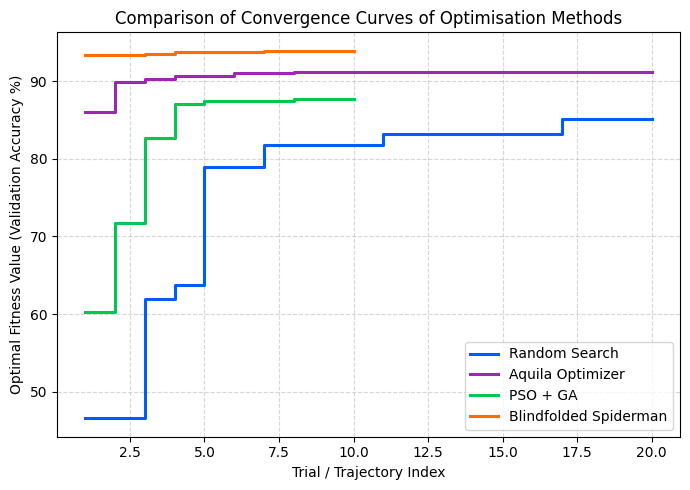

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt


RS_PATH   = "random_search_results.json"
AO_PATH   = "ao_results_all_seeds_combined.json"
DPSO_PATH = "dpso_ga_results_all_seeds.json"
BSO_PATH  = "bso_blindfolded_all_seeds_merged.json"

with open(RS_PATH, "r") as f:
    rs_data = json.load(f)

with open(AO_PATH, "r") as f:
    ao_raw = json.load(f)

with open(DPSO_PATH, "r") as f:
    dpso_raw = json.load(f)

with open(BSO_PATH, "r") as f:
    bso_data = json.load(f)

ao_data   = ao_raw[0]   if isinstance(ao_raw, list)   else ao_raw
dpso_data = dpso_raw[0] if isinstance(dpso_raw, list) else dpso_raw




def rs_curves_per_seed(rs_data):
    """Random Search: best-so-far val_acc per TRIAL for each seed."""
    curves = {}
    for seed_entry in rs_data["seeds_results"]:
        seed = seed_entry["seed"]
        trials = sorted(seed_entry["trials"], key=lambda t: t["trial_no"])
        best = []
        best_so_far = -np.inf
        for t in trials:
            best_so_far = max(best_so_far, t["val_acc"])
            best.append(best_so_far)
        curves[seed] = np.array(best, dtype=float)
    return curves


def ao_curves_per_seed(ao_data):
    """Aquila Optimizer: best-so-far val_acc per TRIAL (not per candidate)."""
    curves = {}
    for seed_entry in ao_data["seeds_results"]:
        seed = seed_entry["seed"]
        trials = sorted(seed_entry["trials"], key=lambda t: t["trial_no"])
        best = []
        best_so_far = -np.inf
        for tr in trials:
            if "best_val_acc_so_far" in tr:
                best_so_far = tr["best_val_acc_so_far"]
            else:
                trial_best = max(c["val_acc"] for c in tr["candidates"])
                best_so_far = max(best_so_far, trial_best)
            best.append(best_so_far)
        curves[seed] = np.array(best, dtype=float)
    return curves


def dpso_curves_per_seed(dpso_data):
    """PSO+GA: best-so-far val_acc per ITERATION / TRIAL."""
    curves = {}
    for seed_entry in dpso_data["seeds_results"]:
        seed = seed_entry["seed"]
        trials = sorted(seed_entry["trials"], key=lambda t: t["trial_no"])
        best = []
        best_so_far = -np.inf
        for tr in trials:
            # try global/best key names, fall back to particles
            if "best_val_acc_so_far" in tr:
                best_so_far = tr["best_val_acc_so_far"]
            elif "global_best_val_acc" in tr:
                best_so_far = tr["global_best_val_acc"]
            else:
                iter_best = max(p["val_acc"] for p in tr["particles"])
                best_so_far = max(best_so_far, iter_best)
            best.append(best_so_far)
        curves[seed] = np.array(best, dtype=float)
    return curves


def bso_curves_per_seed(bso_data):
    """
    Blindfolded Spiderman:
    best-so-far val_acc at the END of each TRAJECTORY.
    """
    curves = {}
    for seed_entry in bso_data["seeds_results"]:
        seed = seed_entry["seed"]
        trajectories = sorted(seed_entry["trajectories"],
                              key=lambda tr: tr["trajectory_no"])
        best = []
        best_so_far = -np.inf
        for traj in trajectories:
            steps = sorted(traj["steps"], key=lambda s: s["step_no"])
            for st in steps:
                best_so_far = max(best_so_far, st["val_acc"])
            best.append(best_so_far)
        curves[seed] = np.array(best, dtype=float)
    return curves


rs_curves  = rs_curves_per_seed(rs_data)
ao_curves  = ao_curves_per_seed(ao_data)
dpso_curves = dpso_curves_per_seed(dpso_data)
bso_curves  = bso_curves_per_seed(bso_data)




def avg_curve(curves_dict, max_len):
    """
    curves_dict: {seed -> 1D array of best-so-far accuracies}
    max_len: number of trials/trajectories to keep (20 or 10)
    Returns x, mean_y where y is averaged over seeds.
    Truncates each seed curve to min(len(curve), max_len),
    then uses the minimum length across seeds.
    """
    lengths = [min(len(v), max_len) for v in curves_dict.values()]
    L = min(lengths)
    x = np.arange(1, L + 1)
    stacked = np.vstack([v[:L] for v in curves_dict.values()])
    mean_y = stacked.mean(axis=0)
    return x, mean_y


rs_x,  rs_mean  = avg_curve(rs_curves,  max_len=20)
ao_x,  ao_mean  = avg_curve(ao_curves,  max_len=20)

dpso_x, dpso_mean = avg_curve(dpso_curves, max_len=10)
bso_x,  bso_mean  = avg_curve(bso_curves,  max_len=10)




# vibrant colours
COLOR_RS   = "#005CFF"
COLOR_PSO  = "#00C853"
COLOR_AO   = "#9C27B0"
COLOR_BSO  = "#FF6D00"

plt.figure(figsize=(7, 5))

plt.plot(rs_x,   rs_mean  * 100, label="Random Search",
         color=COLOR_RS,  linewidth=2.2, drawstyle="steps-post")
plt.plot(ao_x,   ao_mean  * 100, label="Aquila Optimizer",
         color=COLOR_AO,  linewidth=2.2, drawstyle="steps-post")
plt.plot(dpso_x, dpso_mean * 100, label="PSO + GA",
         color=COLOR_PSO, linewidth=2.2, drawstyle="steps-post")
plt.plot(bso_x,  bso_mean * 100, label="Blindfolded Spiderman",
         color=COLOR_BSO, linewidth=2.2, drawstyle="steps-post")

plt.xlabel("Trial / Trajectory Index")
plt.ylabel("Optimal Fitness Value (Validation Accuracy %)")
plt.title("Comparison of Convergence Curves of Optimisation Methods")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("fig_convergence_trials_trajectories_4methods.png", dpi=300)
plt.show()
